## import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import classification_report #This gives Precision, Recall, F1-score, and Support for each class.

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

### load dataset

In [2]:
df=pd.read_csv("heart_disease.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'heart_disease.csv'

## understand the Data

In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

## EDA (Exploratory Data Analysis)

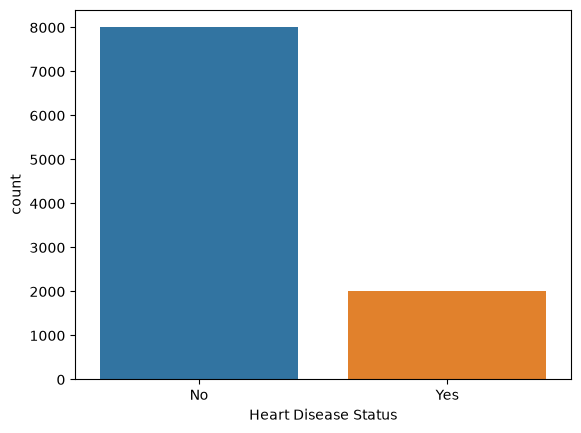

In [ ]:
sns.countplot(data=df,x='Heart Disease Status',hue="Heart Disease Status")

plt.savefig("Heart diseaese status.png")

<Axes: xlabel='Age', ylabel='Count'>

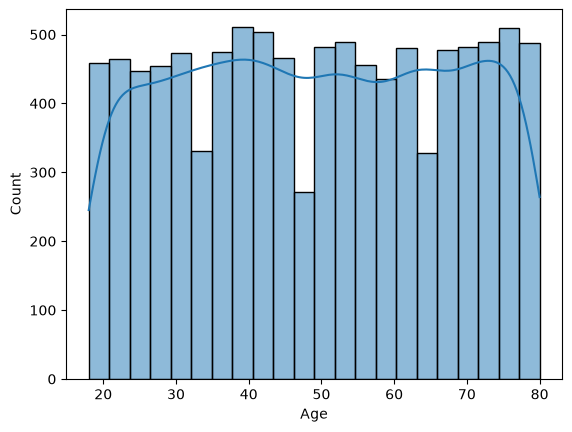

In [ ]:
sns.histplot(df["Age"], kde=True)



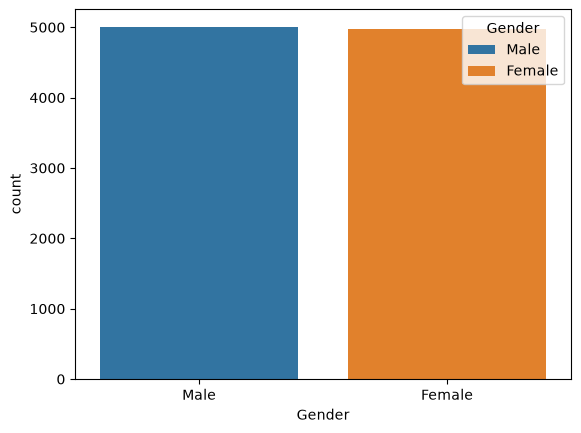

In [ ]:
sns.countplot(data=df,x="Gender",hue="Gender")

plt.savefig("Gender.png")

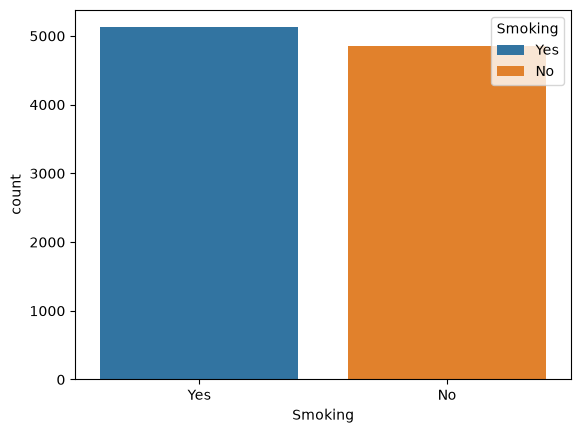

In [ ]:
sns.countplot(data=df,x="Smoking",hue="Smoking")

plt.savefig("No_smokers.png")

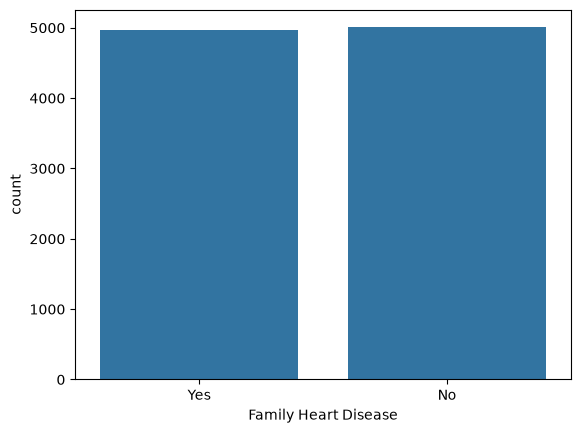

In [ ]:
sns.countplot(data=df,x="Family Heart Disease")

plt.savefig("Family Heart Disease issued.png")

# Data processing

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [ ]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

## fill missing values

In [ ]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if col != "Heart Disease Status":   # target has no missing values
        df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19360\2475168989.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   Gender                10000 non-null  str    
 2   Blood Pressure        10000 non-null  float64
 3   Cholesterol Level     10000 non-null  float64
 4   Exercise Habits       10000 non-null  str    
 5   Smoking               10000 non-null  str    
 6   Family Heart Disease  10000 non-null  str    
 7   Diabetes              10000 non-null  str    
 8   BMI                   10000 non-null  float64
 9   High Blood Pressure   10000 non-null  str    
 10  Low HDL Cholesterol   10000 non-null  str    
 11  High LDL Cholesterol  10000 non-null  str    
 12  Alcohol Consumption   10000 non-null  str    
 13  Stress Level          10000 non-null  str    
 14  Sleep Hours           10000 non-null  float64
 15  Sugar Consumption     10000 non

In [ ]:
df.isnull().sum().sum()

np.int64(0)

## handle Outliers data
An outlier is a data value that is much smaller or much larger than the other values in the dataset.  

In simple words:  

An outlier is a value that is very different from the rest of the data.  

- Example:  
Suppose we have the ages of students in a class  
[18,19,20,21,22,20,19,18,85]  
But:[85] is ver far away from other so   
**85 is an outlier**

## check outlier

In [ ]:
# convert col into numerieric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

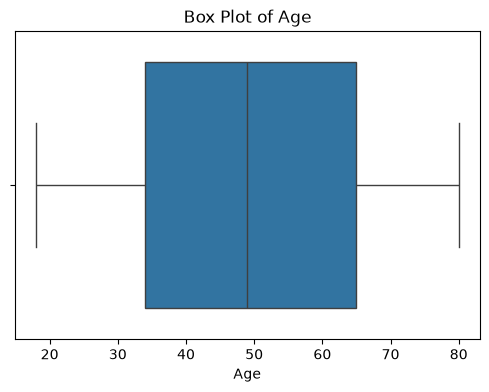

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.show()

## What is an Encoded Category?  
Definition  

Encoded category means converting text (categorical data) into numbers so that a machine learning model can understand it.  

In simple words:  

Encoding = Converting words into numbers.  

In [ ]:
# Find all categorical columns

cat_cols=df.select_dtypes(include="object").columns
cat_cols

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19360\1849193803.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object").columns


Index(['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
       'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
       'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
       'Sugar Consumption', 'Heart Disease Status'],
      dtype='str')

In [ ]:
# find unipe values for each columns
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("_"*40)

Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
________________________________________
Exercise Habits
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
________________________________________
Smoking
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
________________________________________
Family Heart Disease
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
________________________________________
Diabetes
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
________________________________________
High Blood Pressure
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
________________________________________
Low HDL Cholesterol
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
________________________________________
High LDL Cholesterol
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
________________________________________
Alcohol Consumption
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
________________________________________
Stress Lev

## convert "yes/no" values into 0 and 1

In [ ]:
df=df.replace({
    "No":0,
    "Yes":1
})

df=df.replace({
    "Low":0,
    "Medium":1,
    "High":2
})

df["Gender"]=df["Gender"].map({
    "Male":0,
    "Female":1
})

In [ ]:
# check 
cat_cols=df.select_dtypes(include="object").columns
print(cat_cols)

for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("_"*40)

Index(['Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sugar Consumption',
       'Heart Disease Status'],
      dtype='str')
Exercise Habits
[2 0 1]
________________________________________
Smoking
[1 0]
________________________________________
Family Heart Disease
[1 0]
________________________________________
Diabetes
[0 1]
________________________________________
High Blood Pressure
[1 0]
________________________________________
Low HDL Cholesterol
[1 0]
________________________________________
High LDL Cholesterol
[0 1]
________________________________________
Alcohol Consumption
[2 1 0]
________________________________________
Stress Level
[1 2 0]
________________________________________
Sugar Consumption
[1 0 2]
________________________________________
Heart Disease Status
[0 1]
________________________________________


## convert datatypes

In [ ]:
df.dtypes

Age                     float64
Gender                    int64
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object

In [ ]:
df=df.astype({
    "Exercise Habits":float,
    "Smoking":"Int32",
    "Family Heart Disease":int,
    "Diabetes":int,
    "BMI":float,
    "High Blood Pressure":float,
    "Low HDL Cholesterol":float,
    "High LDL Cholesterol":float,
    "Alcohol Consumption":int,
    "Stress Level":int,
    "Sugar Consumption":int,
    "Heart Disease Status":int
})

In [ ]:
df.dtypes

Age                     float64
Gender                    int64
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits         float64
Smoking                   Int32
Family Heart Disease      int64
Diabetes                  int64
BMI                     float64
High Blood Pressure     float64
Low HDL Cholesterol     float64
High LDL Cholesterol    float64
Alcohol Consumption       int64
Stress Level              int64
Sleep Hours             float64
Sugar Consumption         int64
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status      int64
dtype: object

## Feature Selection

In [ ]:
X=df.drop("Heart Disease Status",axis=1)
y=df["Heart Disease Status"]

# train model

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [ ]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, ..., 1, 0, 0], shape=(2500,))

## Model valuation

In [ ]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

accuracy_score: 0.6712
precision_score: 0.20512820512820512
recall_score: 0.224
f1_score: 0.21414913957934992
confusion_matrix:
 [[1566  434]
 [ 388  112]]


## display confusion metrix

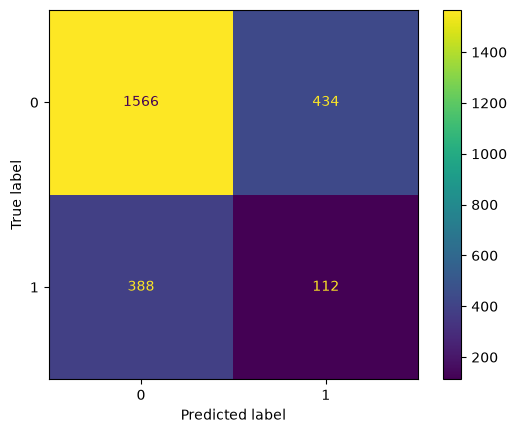

In [ ]:
conusion_M=(y_test,y_pred)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.savefig("Conusion Matrix plot.png")

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2000
           1       0.21      0.22      0.21       500

    accuracy                           0.67      2500
   macro avg       0.50      0.50      0.50      2500
weighted avg       0.68      0.67      0.68      2500



# hyperparameter tuning

# ***GridSearchCV***

In [ ]:
grid_para = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

In [ ]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    grid_para,
    cv=5,
    scoring="f1"
)

In [ ]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",

### best parameter


In [ ]:
print(grid.best_params_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


### best model

In [ ]:
print(grid.best_estimator_)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)


### bst score

In [ ]:
print(grid.best_score_)

0.3034952573869244


In [ ]:
y_pred_grid=grid.predict(x_test)

# Evaluation of GridSearchCV

In [ ]:
print("accuracy_score:",accuracy_score(y_test,y_pred_grid))
print("precision_score:",precision_score(y_test,y_pred_grid))
print("recall_score:",recall_score(y_test,y_pred_grid))
print("f1_score:",f1_score(y_test,y_pred_grid))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred_grid))

accuracy_score: 0.5604
precision_score: 0.18638743455497384
recall_score: 0.356
f1_score: 0.24467353951890033
confusion_matrix:
 [[1223  777]
 [ 322  178]]


## GridSearchCV confusion matrix

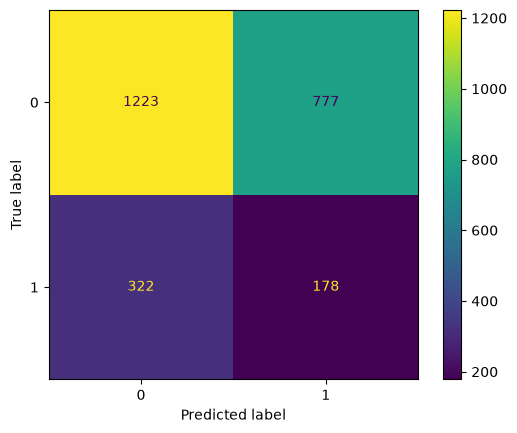

In [ ]:
conusion_M=(y_test,y_pred_grid)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_grid)

plt.savefig("Conusion Matrix gridsearchcv plot.png")

# ***RandomizedSearchCV***

In [ ]:
rand_para = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

In [ ]:
Rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    rand_para,
    cv=5,
    scoring="f1",
    random_state=42
)

In [ ]:
Rand.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also fo

### best parameter

In [ ]:
print(Rand.best_params_)

{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced'}


### bst model

In [ ]:
print(Rand.best_estimator_)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_split=5, random_state=42)


### best score

In [ ]:
print(Rand.best_score_)

0.2969496285206161


In [ ]:
y_pred_rand=Rand.predict(x_test) 

In [ ]:
print("accuracy_score:",accuracy_score(y_test,y_pred_rand))
print("precision_score:",precision_score(y_test,y_pred_rand))
print("recall_score:",recall_score(y_test,y_pred_rand))
print("f1_score:",f1_score(y_test,y_pred_rand))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred_rand))

accuracy_score: 0.6276
precision_score: 0.18722786647314948
recall_score: 0.258
f1_score: 0.21698906644238855
confusion_matrix:
 [[1440  560]
 [ 371  129]]


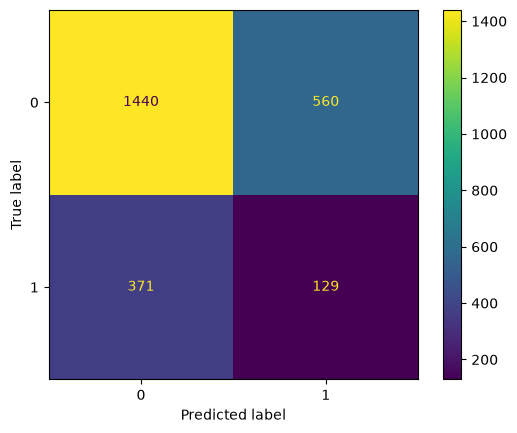

In [ ]:
conusion_M=(y_test,y_pred_rand)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rand)

plt.savefig("Conusion Matrix randomizedsearchcv plot.png")

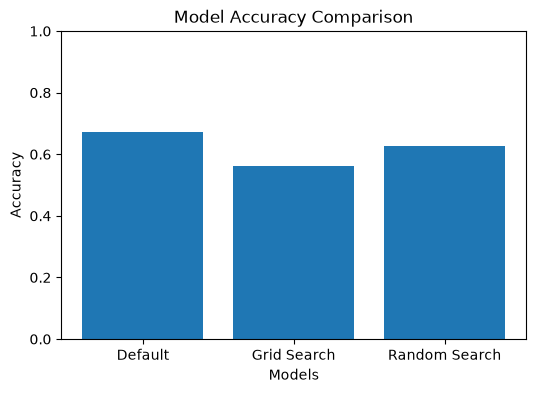

In [ ]:
accuracy_default = accuracy_score(y_test, y_pred)

accuracy_grid = accuracy_score(y_test, y_pred_grid)

accuracy_random = accuracy_score(y_test, y_pred_rand)

models = ['Default', 'Grid Search', 'Random Search']
accuracies = [accuracy_default, accuracy_grid, accuracy_random]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)   # Accuracy ranges from 0 to 1

plt.savefig("final bar chart.png")

In [ ]:
 
comparison = pd.DataFrame({
    "Model": ["Default", "GridSearchCV", "RandomizedSearchCV"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_rand)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_grid),
        precision_score(y_test, y_pred_rand)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_grid),
        recall_score(y_test, y_pred_rand)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_rand)
    ]
})

print(comparison)

                Model  Accuracy  Precision  Recall  F1-Score
0             Default    0.6712   0.205128   0.224  0.214149
1        GridSearchCV    0.5604   0.186387   0.356  0.244674
2  RandomizedSearchCV    0.6276   0.187228   0.258  0.216989


In [ ]:
print(pd.Series(y_pred_grid).value_counts())
print(pd.Series(y_pred_rand).value_counts())

0    1545
1     955
Name: count, dtype: int64
0    1811
1     689
Name: count, dtype: int64


# save model

In [ ]:
import joblib

# joblib.dump(model, "decision_tree_default.pkl")

joblib.dump(grid.best_estimator_, "decision_tree_grid.pkl")

# joblib.dump(Rand.best_estimator_, "decision_tree_random.pkl")

['decision_tree_grid.pkl']

why gride model save becuse his accuracy is high the another 2

In [4]:
import joblib

# Save Default Decision Tree
joblib.dump(
    model,
    "heart_default.pkl"
)

# Save GridSearchCV best model
joblib.dump(
    grid.best_estimator_,
    "heart_grid.pkl"
)

# Save RandomizedSearchCV best model
joblib.dump(
    Rand.best_estimator_,
    "heart_random.pkl"
)

print("All Heart Disease models saved successfully!")

NameError: name 'model' is not defined